In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import *

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [3]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [5]:
X = df.drop("target",axis=1)
y= df["target"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [7]:
svc_model = SVC(kernel='linear')

svc_model.fit(X_train, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
y_pred = svc_model.predict(X_test)

In [10]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



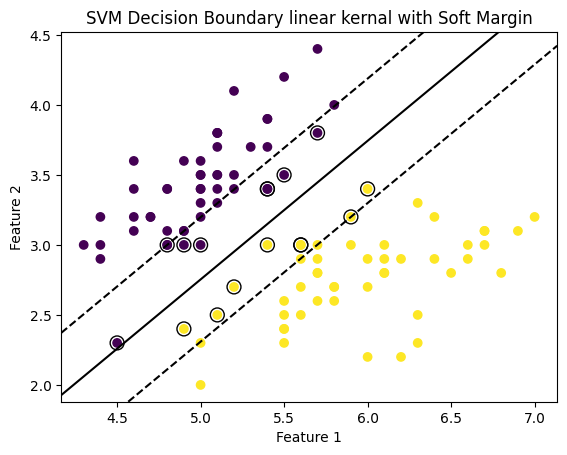

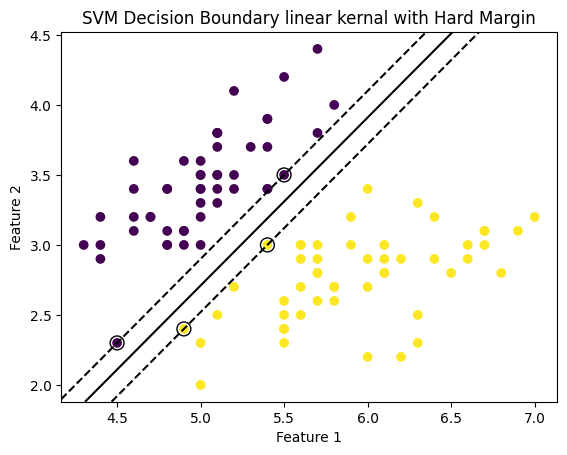

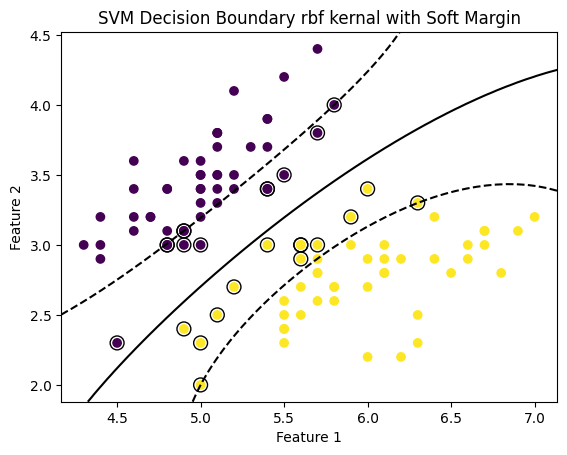

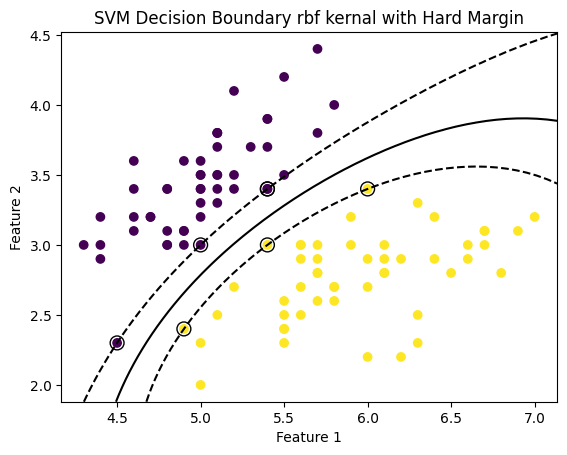

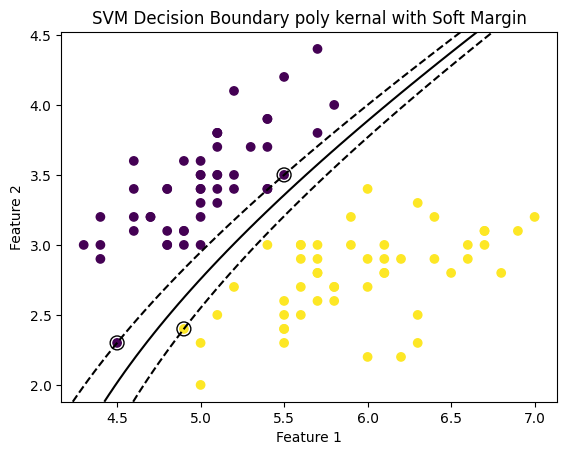

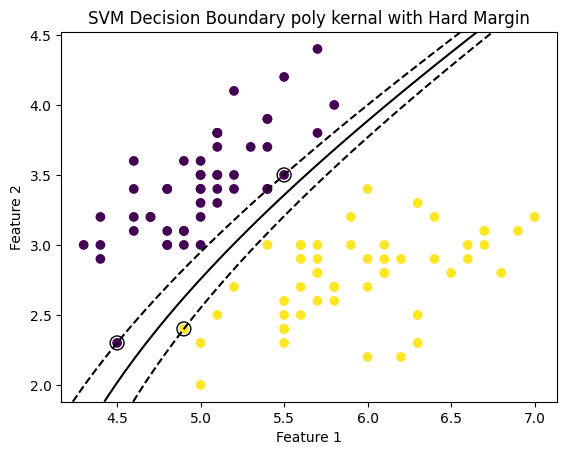

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]   # first 2 features
y = iris.target

# Use only 2 classes for clarity
mask = y != 2
X = X[mask]
y = y[mask]

k = ['linear', 'rbf', 'poly']
c = [1,1e10]
for i in k:
    for j in c:
    # Train SVM model
        model = SVC(kernel=i,C=j)
        model.fit(X, y)

        # Plot data points
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')

        # Get current axis
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        # Create grid
        xx = np.linspace(xlim[0], xlim[1], 50)
        yy = np.linspace(ylim[0], ylim[1], 50)
        YY, XX = np.meshgrid(yy, xx)

        # Stack into input for prediction
        xy = np.vstack([XX.ravel(), YY.ravel()]).T

        # Decision function
        Z = model.decision_function(xy)

        # Handle multi-class case
        if len(Z.shape) > 1:
            Z = Z[:, 0]

        Z = Z.reshape(XX.shape)

        # Plot decision boundary
        ax.contour(XX, YY, Z, colors='k', levels=[0])

        # Plot margins
        ax.contour(XX, YY, Z, colors='k', levels=[-1, 1], linestyles=['--', '--'])

        # Highlight support vectors
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, linewidth=1, facecolors='none', edgecolors='k')


        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        if j == 1:
            plt.title(f"SVM Decision Boundary {i} kernal with Soft Margin")
        else:
            plt.title(f"SVM Decision Boundary {i} kernal with Hard Margin")
        plt.show()

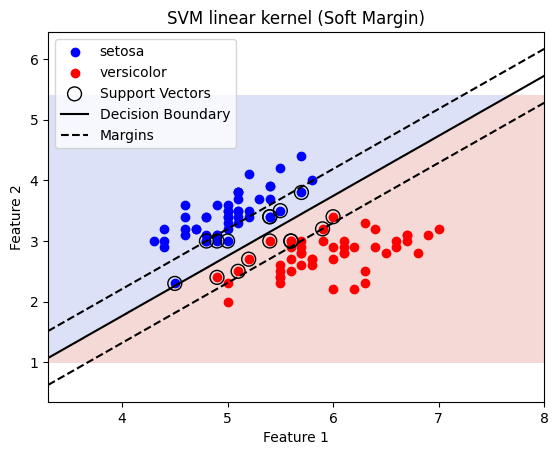

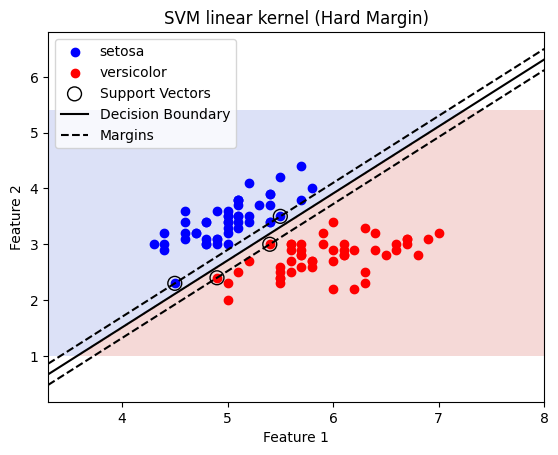

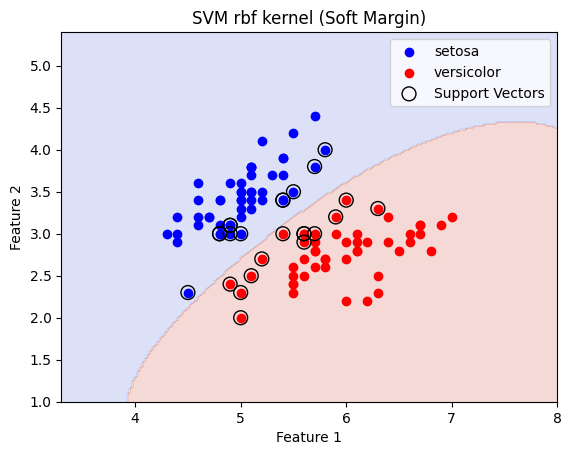

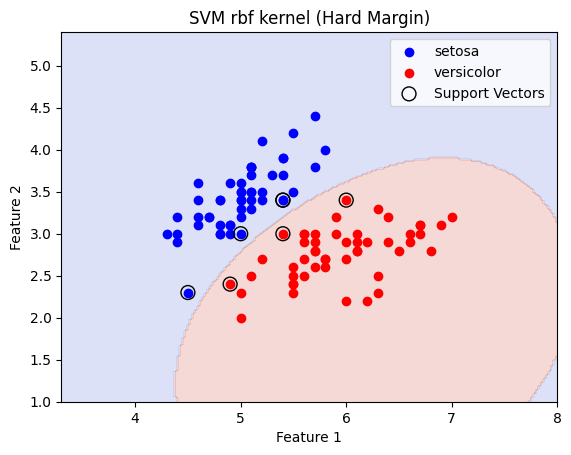

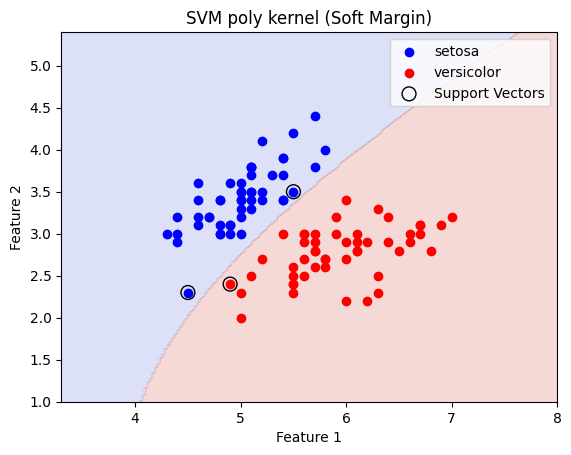

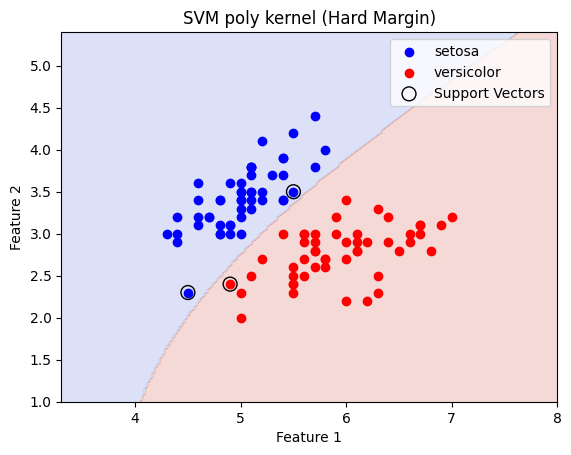

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

# Only 2 classes (for linear boundary clarity)
mask = y != 2
X = X[mask]
y = y[mask]

kernels = ['linear', 'rbf', 'poly']
C_values = [1, 1e10]  # Soft and Hard margin

for kernel in kernels:
    for C_val in C_values:
        plt.figure()

        # Train model
        model = SVC(kernel=kernel, C=C_val, gamma='scale')
        model.fit(X, y)

        # Grid for plotting
        xx, yy = np.meshgrid(
            np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200),
            np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200)
        )
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision regions
        plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')

        # Plot points with class names
        colors = ['blue', 'red']
        for i, name in enumerate(iris.target_names[:2]):
            plt.scatter(X[y == i, 0], X[y == i, 1],
                        label=name, color=colors[i])

        # Highlight support vectors
        plt.scatter(model.support_vectors_[:, 0],
                    model.support_vectors_[:, 1],
                    s=100, facecolors='none',
                    edgecolors='black', label='Support Vectors')

        # Plot linear decision boundary and margins for linear kernel
        if kernel == 'linear':
            w = model.coef_[0]
            b = model.intercept_[0]
            x_plot = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
            y_plot = -(w[0]*x_plot + b)/w[1]
            y_margin1 = -(w[0]*x_plot + b - 1)/w[1]
            y_margin2 = -(w[0]*x_plot + b + 1)/w[1]

            plt.plot(x_plot, y_plot, 'k-', label='Decision Boundary')
            plt.plot(x_plot, y_margin1, 'k--', label='Margins')
            plt.plot(x_plot, y_margin2, 'k--')

        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        margin_type = "Soft Margin" if C_val == 1 else "Hard Margin"
        plt.title(f"SVM {kernel} kernel ({margin_type})")
        plt.legend()
        plt.show()